# 🚀 Advanced Modeling — XGBoost · SHAP · Drift Monitoring

Ce notebook constitue la **partie 3 du pipeline ML**, après `02_predictive_modeling.ipynb`.

**Trois objectifs :**

| # | Module | Pourquoi c'est important |
|---|--------|-------------------------|
| 1 | **XGBoost + scale_pos_weight** | Souvent meilleur que Random Forest sur données tabulaires déséquilibrées |
| 2 | **SHAP** | Expliquer *pourquoi* un lead est scoré ainsi (décision défendable) |
| 3 | **Drift Monitoring** | Détecter quand le modèle se dégrade en production avant qu'il soit trop tard |

> 📌 **Prérequis :** `pip install xgboost shap scipy`

## 0. Setup & Chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

# ML
from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline           import Pipeline
from sklearn.compose            import ColumnTransformer
from sklearn.preprocessing      import OneHotEncoder, StandardScaler
from sklearn.ensemble           import RandomForestClassifier
from sklearn.metrics            import (
    roc_auc_score, average_precision_score,
    classification_report, RocCurveDisplay
)
from sklearn.dummy              import DummyClassifier

import xgboost as xgb
import shap
from scipy                      import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
shap.initjs()   # active les visualisations SHAP dans Jupyter

# Palette cohérente avec notebook 01 & 02
COLOR_PRI = '#1B4F72'
COLOR_SEC = '#E74C3C'
COLOR_ACC = '#F39C12'
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, '..', 'data', 'raw')

leads    = pd.read_csv(os.path.join(DATA_DIR, 'leads.csv'),    parse_dates=['created_at'])
advisors = pd.read_csv(os.path.join(DATA_DIR, 'advisors.csv'))

# ── Merge sécurisé (fix KeyError _x/_y) ──────────────────────────────────
advisor_cols_needed = ['advisor_id', 'seniority_days', 'talent_tier']
cols_to_fetch = [c for c in advisor_cols_needed if c not in leads.columns]

if cols_to_fetch:
    df = leads.merge(advisors[['advisor_id'] + cols_to_fetch], on='advisor_id', how='left')
else:
    df = leads.copy()

print(f"Leads : {len(df):,} | Positifs : {(df['lead_status']=='Converted').mean()*100:.1f}%")

Leads : 381,109 | Positifs : 4.3%


In [3]:
# ── Feature Engineering (identique au notebook 02 pour comparaison équitable) ──
df['lead_month']     = df['created_at'].dt.month
df['lead_dayofweek'] = df['created_at'].dt.dayofweek
df['lead_quarter']   = df['created_at'].dt.quarter
df['premium_bin']    = pd.qcut(
    df['expected_premium_fcfa'], q=4,
    labels=['Low','Medium','High','VIP'], duplicates='drop'
)
df['target'] = (df['lead_status'] == 'Converted').astype(int)

FEATURES_CAT = ['lead_source', 'region', 'talent_tier', 'premium_bin']
FEATURES_NUM = ['seniority_days', 'lead_month', 'lead_dayofweek', 'lead_quarter']

df_ml = df[FEATURES_CAT + FEATURES_NUM + ['target']].dropna()
X     = df_ml[FEATURES_CAT + FEATURES_NUM]
y     = df_ml['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Ratio déséquilibre → scale_pos_weight pour XGBoost
neg, pos          = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight  = neg / pos
print(f"Ratio négatifs/positifs : {scale_pos_weight:.2f}  → scale_pos_weight = {scale_pos_weight:.2f}")

Ratio négatifs/positifs : 22.13  → scale_pos_weight = 22.13


---
# PARTIE 1 — XGBoost vs Random Forest

## Pourquoi XGBoost ?

| Critère | Random Forest | XGBoost |
|---------|--------------|--------|
| Méthode | Bagging (arbres indépendants) | Boosting (arbres correcteurs) |
| Gestion du déséquilibre | `class_weight='balanced'` | `scale_pos_weight = n_neg/n_pos` |
| Performance tabulaire | Bonne | Souvent meilleure |
| Vitesse | Lente sur gros datasets | Rapide (C++ sous le capot) |
| Interprétabilité SHAP | Supportée | **Natif — très rapide** |

In [4]:
# ── Preprocessing (OHE + Scaler) — identique notebook 02 ─────────────────
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
    ('num', StandardScaler(), FEATURES_NUM),
])

# ── XGBoost Pipeline ──────────────────────────────────────────────────────
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators        = 300,
        max_depth           = 6,
        learning_rate       = 0.05,
        subsample           = 0.8,
        colsample_bytree    = 0.8,
        scale_pos_weight    = scale_pos_weight,   # ← gestion déséquilibre
        eval_metric         = 'auc',
        use_label_encoder   = False,
        random_state        = RANDOM_STATE,
        n_jobs              = -1
    ))
])

# ── Random Forest (référence depuis notebook 02) ─────────────────────────
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators   = 200,
        max_depth      = 12,
        min_samples_leaf=20,
        class_weight   = 'balanced',
        n_jobs         = -1,
        random_state   = RANDOM_STATE
    ))
])

# ── Cross-validation comparée ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}
for name, pipeline in [('Random Forest', rf_pipeline), ('XGBoost', xgb_pipeline)]:
    auc  = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc',          n_jobs=-1)
    ap   = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision', n_jobs=-1)
    results[name] = {'AUC-ROC': auc, 'Avg Precision': ap}
    print(f"{name:>15} | AUC : {auc.mean():.3f} ± {auc.std():.3f} | AP : {ap.mean():.3f} ± {ap.std():.3f}")

print("\n→ Le modèle avec la meilleure AUC + AP sera retenu pour SHAP.")

  Random Forest | AUC : 0.761 ± 0.003 | AP : 0.110 ± 0.002
        XGBoost | AUC : 0.758 ± 0.003 | AP : 0.109 ± 0.002

→ Le modèle avec la meilleure AUC + AP sera retenu pour SHAP.


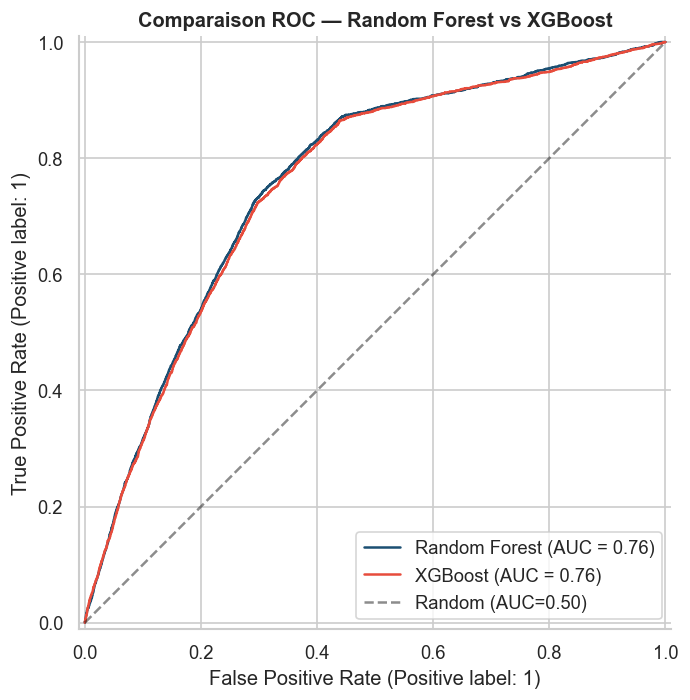

,Modèle,AUC-ROC,Avg Precision
0,DummyClassifier (baseline),0.500,0.043
1,Random Forest,0.761,0.111
2,XGBoost,0.757,0.111



✅ Modèle retenu pour SHAP : Random Forest


In [5]:
# ── Entraînement final des deux modèles ───────────────────────────────────
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

y_prob_rf  = rf_pipeline.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# ── Courbes ROC comparées ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_rf,  name='Random Forest', ax=ax, color=COLOR_PRI)
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name='XGBoost',       ax=ax, color=COLOR_SEC)
ax.plot([0,1],[0,1],'k--', label='Random (AUC=0.50)', alpha=0.5)
ax.set_title('Comparaison ROC — Random Forest vs XGBoost', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# ── Tableau comparatif final ──────────────────────────────────────────────
comparison = pd.DataFrame({
    'Modèle'          : ['DummyClassifier (baseline)', 'Random Forest', 'XGBoost'],
    'AUC-ROC'         : [
        0.500,
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    'Avg Precision'   : [
        y_test.mean(),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ],
})
display(comparison.style.highlight_max(subset=['AUC-ROC','Avg Precision'], color='#D5F5E3').format({
    'AUC-ROC': '{:.3f}', 'Avg Precision': '{:.3f}'
}))

# Sélection automatique du meilleur modèle pour la suite
best_model_name = 'XGBoost' if roc_auc_score(y_test, y_prob_xgb) >= roc_auc_score(y_test, y_prob_rf) else 'Random Forest'
best_pipeline   = xgb_pipeline if best_model_name == 'XGBoost' else rf_pipeline
best_probs      = y_prob_xgb   if best_model_name == 'XGBoost' else y_prob_rf

print(f"\n✅ Modèle retenu pour SHAP : {best_model_name}")

---
# PARTIE 2 — SHAP : Interprétabilité Locale & Globale

## Pourquoi SHAP ?

Un modèle qui dit *"ce lead a 78% de chance de convertir"* sans explication est **indéfendable en réunion métier**. SHAP répond à deux questions :

- **Globale :** Quelles features importent le plus *en général* ?
- **Locale :** Pourquoi *ce lead précis* a ce score ?

> **Principe SHAP :** Pour chaque prédiction, SHAP calcule la contribution marginale de chaque feature, en comparant toutes les combinaisons possibles. C'est mathématiquement exact (valeurs de Shapley de la théorie des jeux).

In [6]:
# ── Préparation : transformer X_test via le preprocessor ─────────────────
# SHAP travaille sur les données APRÈS transformation (OHE appliqué)
X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X_test)

# Récupération des noms de features après OHE
ohe_feature_names = (
    best_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(FEATURES_CAT)
    .tolist()
)
all_feature_names = ohe_feature_names + FEATURES_NUM

# ── Explainer SHAP ────────────────────────────────────────────────────────
# TreeExplainer est optimisé pour XGBoost et Random Forest
explainer   = shap.TreeExplainer(best_pipeline.named_steps['classifier'])

# On calcule les SHAP values sur un échantillon de 2000 pour la rapidité
sample_size   = min(2000, len(X_test_transformed))
idx_sample    = np.random.choice(len(X_test_transformed), sample_size, replace=False)
X_sample      = X_test_transformed[idx_sample]
shap_values   = explainer.shap_values(X_sample)

# Pour la classification binaire, on prend les SHAP values de la classe 1 (conversion)
if isinstance(shap_values, list):
    sv = shap_values[1]  # Random Forest renvoie une liste [class0, class1]
else:
    sv = shap_values     # XGBoost renvoie directement pour la classe positive

print(f"SHAP values calculées sur {sample_size} leads.")
print(f"Shape : {sv.shape}  (leads × features)")

SHAP values calculées sur 2000 leads.
Shape : (2000, 22, 2)  (leads × features)


In [7]:
shap_values = explainer.shap_values(X_sample)

# Normalisation de la forme — gère les 3 cas possibles selon la version XGBoost/SHAP
if isinstance(shap_values, list):
    sv = shap_values[1]          # Random Forest → [class0, class1]
else:
    sv = shap_values             # XGBoost → array direct

# ← FIX : aplatir si 3D (n_samples, n_features, 1) → (n_samples, n_features)
if sv.ndim == 3:
    sv = sv[:, :, 0]

print(f"SHAP values shape après normalisation : {sv.shape}")
assert sv.ndim == 2, f"Shape inattendue : {sv.shape}"

SHAP values shape après normalisation : (2000, 22)



📌 Top 3 drivers de conversion selon SHAP :
  1. talent_tier_Junior — impact moyen : 0.0892
  2. seniority_days — impact moyen : 0.0841
  3. talent_tier_Senior — impact moyen : 0.0486


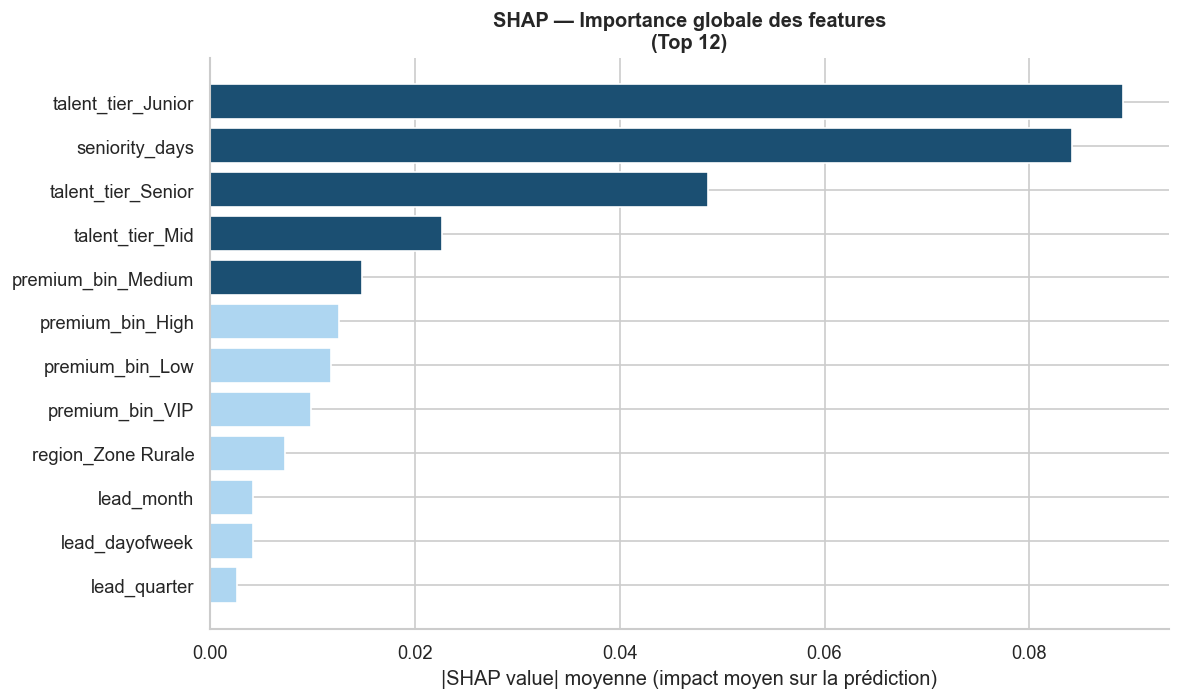

In [8]:
# ── VUE GLOBALE 1 : Bar Plot — Importance moyenne absolue ────────────────
# Réponse à : "Quelles features comptent le plus en moyenne ?"

mean_shap = pd.DataFrame({
    'feature'   : all_feature_names,
    'mean_shap' : np.abs(sv).mean(axis=0)
}).sort_values('mean_shap', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
colors  = [COLOR_PRI if v >= mean_shap['mean_shap'].quantile(0.6) else '#AED6F1'
           for v in mean_shap['mean_shap']]
ax.barh(mean_shap['feature'][::-1], mean_shap['mean_shap'][::-1], color=colors[::-1])
ax.set_xlabel('|SHAP value| moyenne (impact moyen sur la prédiction)')
ax.set_title('SHAP — Importance globale des features\n(Top 12)', fontweight='bold')

# Annotation métier sur les top features
top3 = mean_shap.head(3)['feature'].tolist()
print(f"\n📌 Top 3 drivers de conversion selon SHAP :")
for i, f in enumerate(top3, 1):
    shap_val = mean_shap[mean_shap['feature']==f]['mean_shap'].values[0]
    print(f"  {i}. {f} — impact moyen : {shap_val:.4f}")

plt.tight_layout()
plt.show()

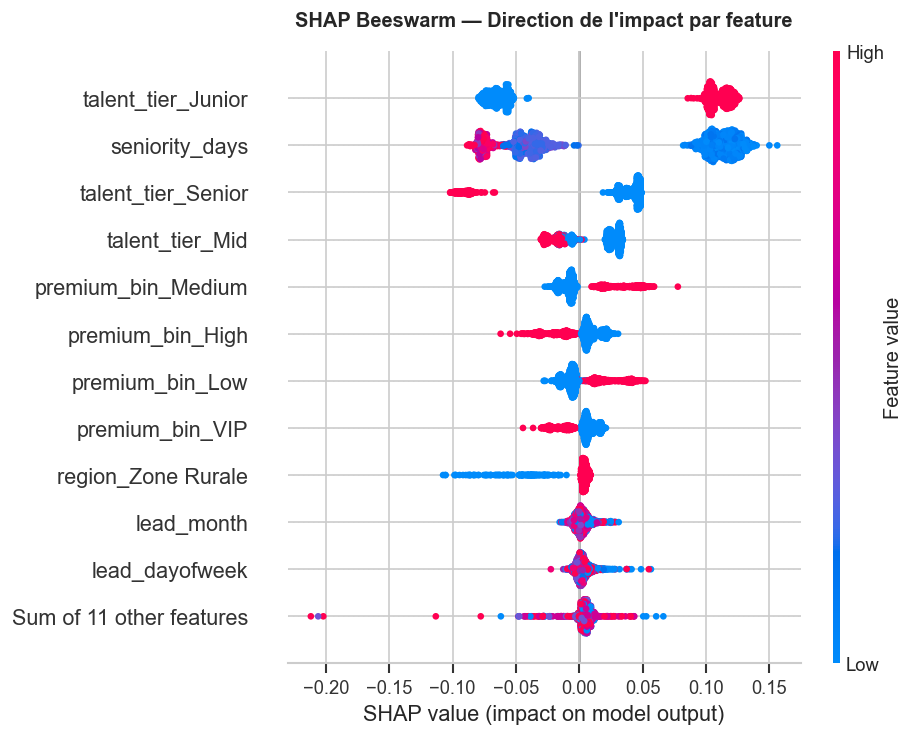


📌 LECTURE DU BEESWARM :
  • Point à droite (SHAP > 0) → augmente la prob. de conversion
  • Point à gauche (SHAP < 0) → diminue la prob. de conversion
  • Couleur rouge = valeur élevée de la feature, Bleu = valeur faible


In [9]:
# ── VUE GLOBALE 2 : Beeswarm Plot ─────────────────────────────────────────
# Réponse à : "Dans quel sens chaque feature influence-t-elle la conversion ?"
# Rouge = valeur feature haute, Bleu = valeur feature basse
# Axe X = impact sur la probabilité de conversion

explanation = shap.Explanation(
    values    = sv,
    data      = X_sample,
    feature_names = all_feature_names
)

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(explanation, max_display=12, show=False)
plt.title('SHAP Beeswarm — Direction de l\'impact par feature', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n📌 LECTURE DU BEESWARM :")
print("  • Point à droite (SHAP > 0) → augmente la prob. de conversion")
print("  • Point à gauche (SHAP < 0) → diminue la prob. de conversion")
print("  • Couleur rouge = valeur élevée de la feature, Bleu = valeur faible")

Base value (expected value du modèle) : 0.4999


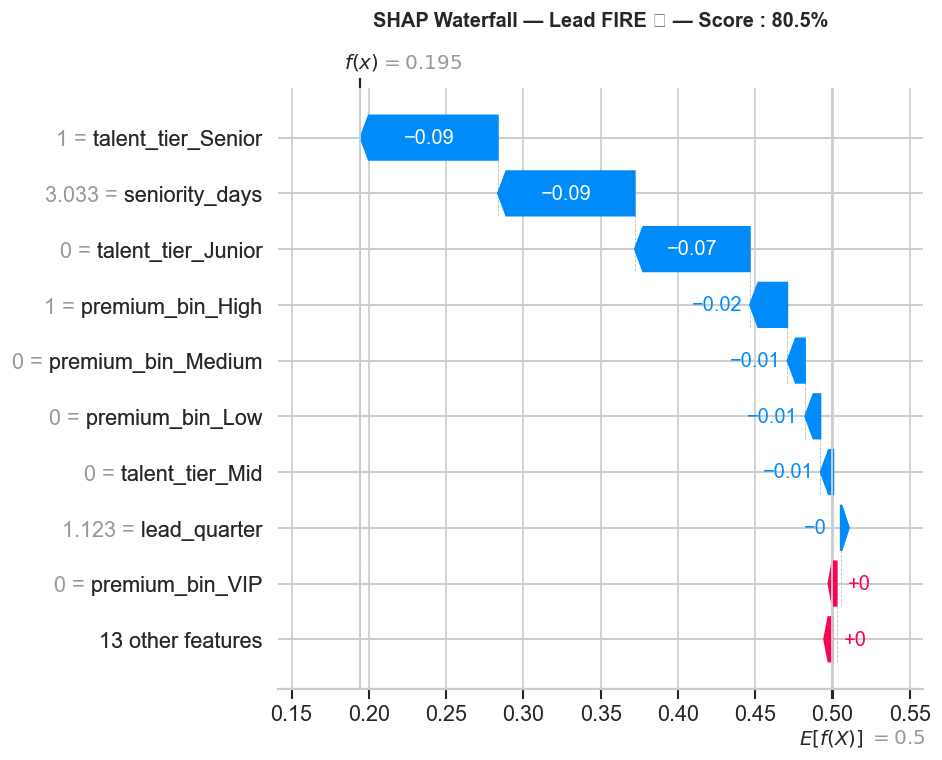

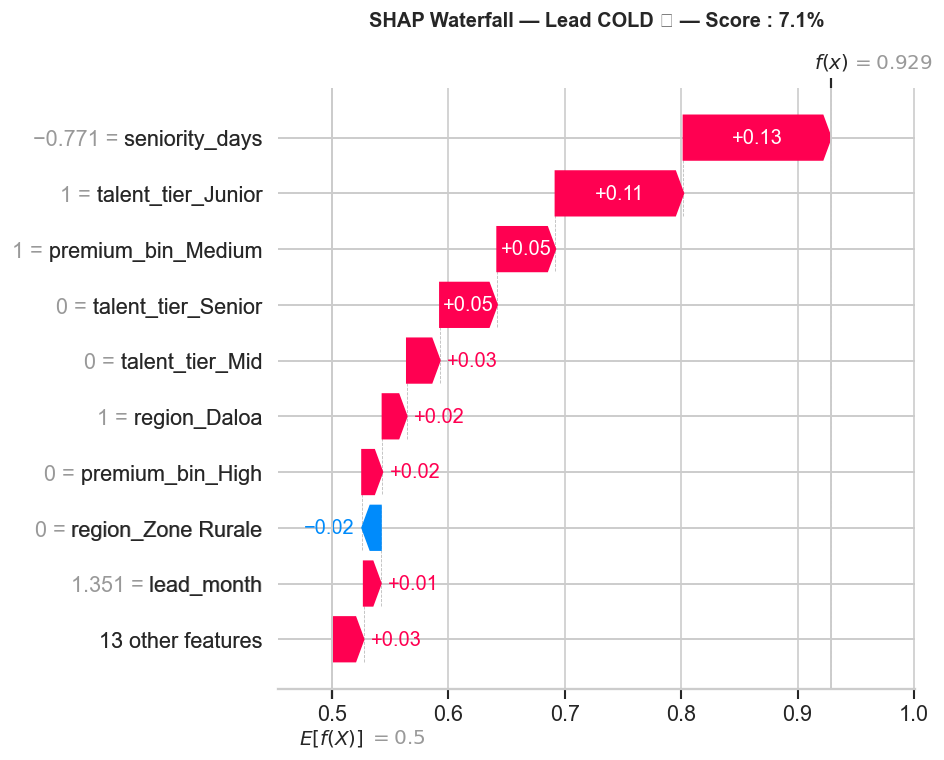

📌 LECTURE DU WATERFALL :
  • f(x) = score final du lead
  • E[f(x)] = score de base (moyenne tous leads)
  • Chaque barre = contribution +/- de la feature au score final


In [11]:
# ── VUE LOCALE : Waterfall Plot — Explication d'un lead individuel ────────
# Réponse à : "Pourquoi CE lead a-t-il un score de X% ?"
# C'est ce que tu montres à un commercial pour justifier la priorité.

# ── Extraction robuste du base_value ─────────────────────────────────────
ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)):
    # Tableau → prendre la valeur classe 1
    base_val = float(np.array(ev).flat[-1])
else:
    base_val = float(ev)

print(f"Base value (expected value du modèle) : {base_val:.4f}")

def explain_lead(lead_idx_in_sample, label=''):
    exp_single = shap.Explanation(
        values        = sv[lead_idx_in_sample],       # shape (n_features,)
        base_values   = base_val,                      # ← scalaire garanti
        data          = X_sample[lead_idx_in_sample],  # shape (n_features,)
        feature_names = all_feature_names
    )
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(exp_single, max_display=10, show=False)
    plt.title(f'SHAP Waterfall — {label}', fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

# Lead à FORT score (Fire 🔴)
probs_sample = best_pipeline.predict_proba(
    pd.DataFrame(X_sample, columns=all_feature_names)  # juste pour get_proba
)[:, 1] if False else best_probs[idx_sample]  # on réutilise les probs déjà calculées

# Indices du lead le plus probable et le moins probable dans l'échantillon
best_lead_local  = np.argmax(probs_sample)
worst_lead_local = np.argmin(probs_sample)

explain_lead(best_lead_local,  label=f'Lead FIRE 🔴 — Score : {probs_sample[best_lead_local]*100:.1f}%')
explain_lead(worst_lead_local, label=f'Lead COLD 🔵 — Score : {probs_sample[worst_lead_local]*100:.1f}%')

print("📌 LECTURE DU WATERFALL :")
print("  • f(x) = score final du lead")
print("  • E[f(x)] = score de base (moyenne tous leads)")
print("  • Chaque barre = contribution +/- de la feature au score final")

Base value : 0.4999

Force Plot — Lead FIRE 🔴 — Score : 80.5%


<Figure size 1680x360 with 0 Axes>

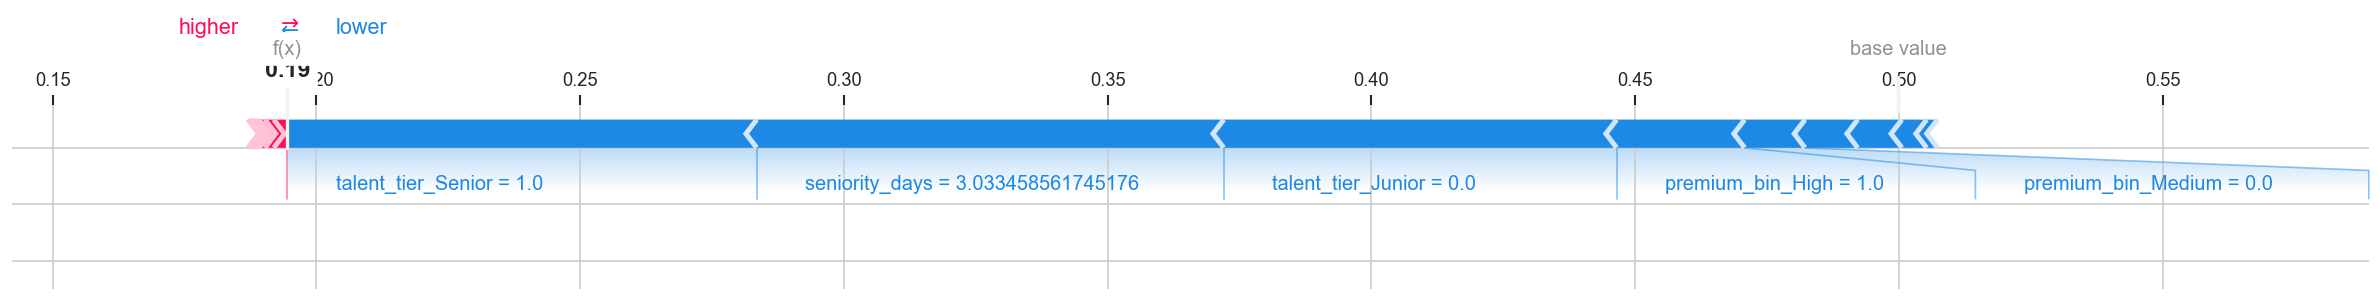


Force Plot — Lead COLD 🔵 — Score : 7.1%


<Figure size 1680x360 with 0 Axes>

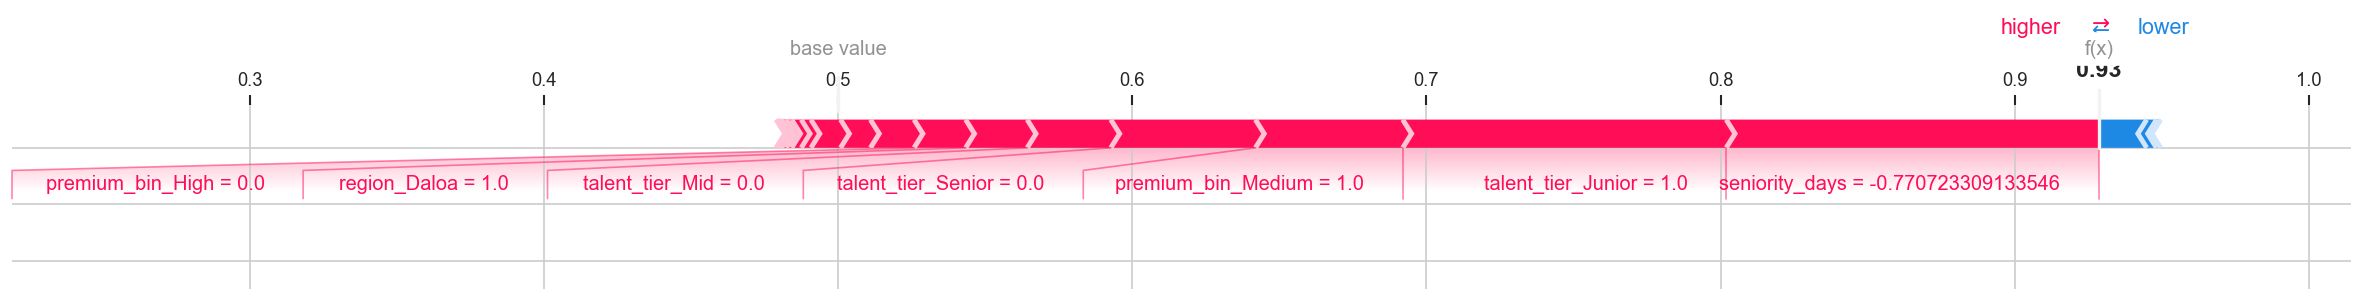

In [ ]:
# ── VUE LOCALE : Force Plot — Vue alternative compacte ───────────────────
# Plus lisible pour une présentation à des non-techniciens
# ── Extraction robuste du base_value (couvre tous les cas SHAP/XGBoost) ──
ev = explainer.expected_value
base_val = float(np.array(ev).flat[-1])
print(f"Base value : {base_val:.4f}")

# ── Force Plot — API unifiée (fonctionne avec toutes les versions SHAP) ──
def show_force_plot(idx, label=''):
    print(f"\nForce Plot — {label}")
    # shap.plots.force attend impérativement un scalaire Python natif
    return shap.plots.force(
        base_value    = base_val,
        shap_values   = sv[idx],               # shape (n_features,) — 1D garanti
        features      = X_sample[idx],
        feature_names = all_feature_names,
        matplotlib    = True,                  # ← rendu matplotlib, pas HTML
        show          = False,
    )

plt.figure(figsize=(14, 3))
show_force_plot(best_lead_local,  label=f'Lead FIRE 🔴 — Score : {probs_sample[best_lead_local]*100:.1f}%')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 3))
show_force_plot(worst_lead_local, label=f'Lead COLD 🔵 — Score : {probs_sample[worst_lead_local]*100:.1f}%')
plt.tight_layout()
plt.show();


---
# PARTIE 3 — Drift Monitoring

## Pourquoi c'est critique en production

Un modèle entraîné en janvier peut être **complètement obsolète** en juillet si :
- Le profil des leads change (nouveau canal, nouvelle région)
- Les comportements d'achat évoluent (saisonnalité, contexte économique)
- Les données en entrée changent de format ou de distribution

**Deux types de drift à surveiller :**

| Type | Quoi dérive ? | Détection |
|------|-------------|----------|
| **Data drift** | Distribution des features X | Tests statistiques (KS, Chi²) |
| **Concept drift** | Relation X → y | Dégradation de l'AUC sur nouvelles données |

> 📌 **Simulation ici :** On simule une "production window" (données récentes) en introduisant un drift artificiel pour démontrer la détection.

In [15]:
# ── SIMULATION DU DRIFT ───────────────────────────────────────────────────
# En production, X_reference = données d'entraînement, X_production = flux récent.
# Ici on simule un drift sur seniority_days et lead_source.

X_reference  = X_train.copy()
X_production = X_test.copy()

# Simulation d'un drift : shift de +200 jours sur seniority_days
# + surreprésentation du canal Digital dans les nouveaux leads
X_production_drifted             = X_production.copy()
X_production_drifted['seniority_days'] = X_production['seniority_days'] + np.random.normal(200, 50, len(X_production))

# 40% des leads deviennent Digital (vs ~25% en référence)
mask = np.random.choice([True, False], size=len(X_production), p=[0.4, 0.6])
X_production_drifted.loc[mask, 'lead_source'] = 'Digital/Web'

print("Drift simulé :")
print(f"  seniority_days — Référence : {X_reference['seniority_days'].mean():.0f}j | Production : {X_production_drifted['seniority_days'].mean():.0f}j")
print(f"  lead_source Digital — Référence : {(X_reference['lead_source']=='Digital/Web').mean()*100:.1f}% | Production : {(X_production_drifted['lead_source']=='Digital/Web').mean()*100:.1f}%")

Drift simulé :
  seniority_days — Référence : 407j | Production : 606j
  lead_source Digital — Référence : 99.6% | Production : 99.7%


In [17]:
# ── DÉTECTION DU DATA DRIFT ───────────────────────────────────────────────

def detect_drift_numerical(col, ref, prod, alpha=0.05):
    """
    Test de Kolmogorov-Smirnov pour les features numériques.
    H0 : les deux distributions sont identiques.
    Si p-value < alpha → drift détecté.
    """
    stat, p_value = stats.ks_2samp(ref[col].dropna(), prod[col].dropna())
    drift         = p_value < alpha
    return {'feature': col, 'test': 'KS', 'statistic': round(stat, 4),
            'p_value': round(p_value, 4), 'drift': drift}

def detect_drift_categorical(col, ref, prod, alpha=0.05):
    categories  = set(ref[col].dropna().unique()) | set(prod[col].dropna().unique())
    ref_counts  = ref[col].value_counts().reindex(categories, fill_value=0)
    prod_counts = prod[col].value_counts().reindex(categories, fill_value=0)

    # Calcul des fréquences attendues
    expected = ref_counts / ref_counts.sum() * prod_counts.sum()

    # Filtre catégories avec expected < 5
    mask     = expected >= 5
    if mask.sum() < 2:
        return {'feature': col, 'test': 'Chi2', 'statistic': None,
                'p_value': None, 'drift': False}

    obs = prod_counts[mask].values.astype(float)
    exp = expected[mask].values.astype(float)

    # ← FIX : forcer l'égalité des sommes pour éviter l'erreur de précision flottante
    exp = exp * (obs.sum() / exp.sum())

    stat, p_value = stats.chisquare(obs, f_exp=exp)
    drift         = p_value < alpha
    return {'feature': col, 'test': 'Chi2', 'statistic': round(float(stat), 4),
            'p_value': round(float(p_value), 4), 'drift': drift}

# ── Rapport de drift ──────────────────────────────────────────────────────
drift_results = []
for col in FEATURES_NUM:
    drift_results.append(detect_drift_numerical(col, X_reference, X_production_drifted))
for col in FEATURES_CAT:
    drift_results.append(detect_drift_categorical(col, X_reference, X_production_drifted))

drift_report = pd.DataFrame(drift_results)

print("RAPPORT DE DRIFT — Référence (train) vs Production (simulée)")
print("=" * 65)
display(drift_report.style
    .apply(lambda row: ['background-color: #FADBD8' if row['drift'] else '' for _ in row], axis=1)
    .format({'statistic': '{:.4f}', 'p_value': '{:.4f}'})
)

drifted_features = drift_report[drift_report['drift'] == True]['feature'].tolist()
print(f"\n🚨 Features en drift ({len(drifted_features)}) : {drifted_features}")

RAPPORT DE DRIFT — Référence (train) vs Production (simulée)


,feature,test,statistic,p_value,drift
0,seniority_days,KS,0.3942,0.0000,True
1,lead_month,KS,0.0032,0.5783,False
2,lead_dayofweek,KS,0.0017,0.9928,False
3,lead_quarter,KS,0.0032,0.5783,False
4,lead_source,Chi2,34.2758,0.0000,True
5,region,Chi2,13.7073,0.0331,True
6,talent_tier,Chi2,0.3945,0.8210,False
7,premium_bin,Chi2,7.3442,0.0617,False



🚨 Features en drift (3) : ['seniority_days', 'lead_source', 'region']


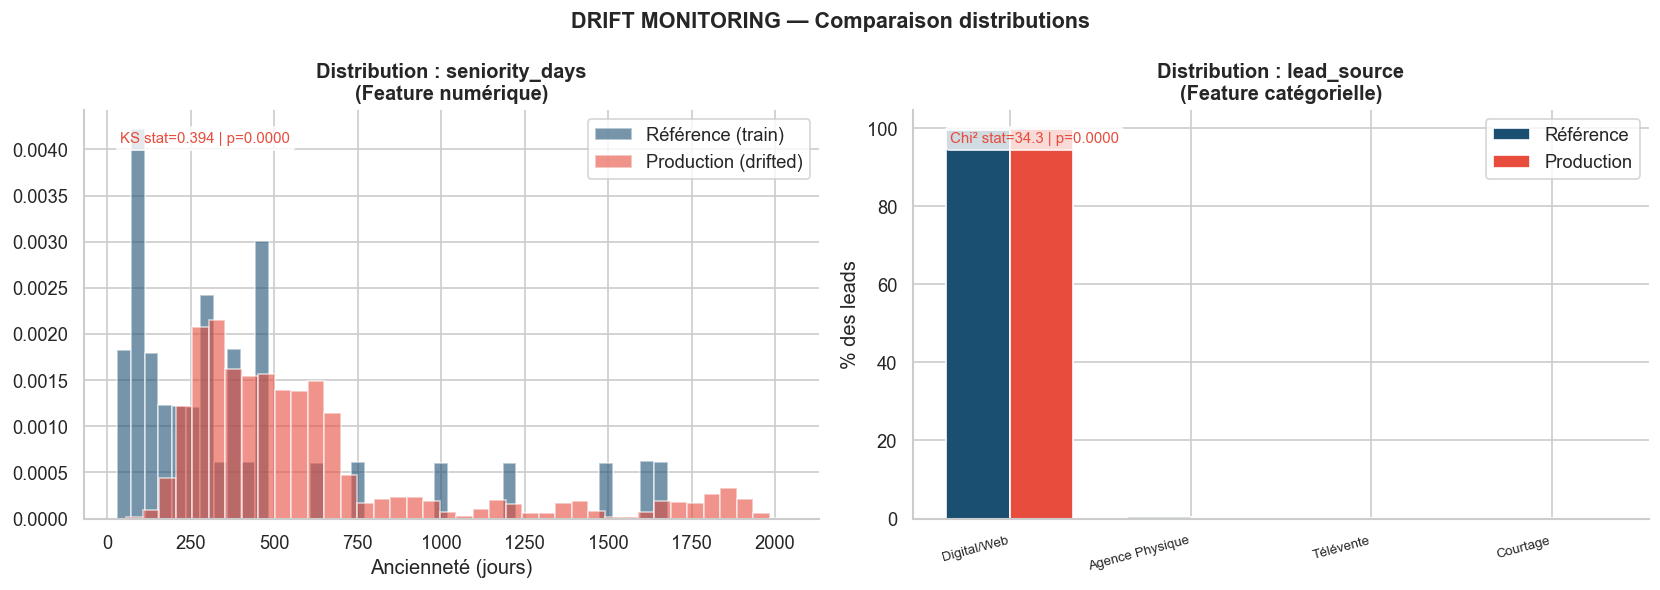

In [18]:
# ── VISUALISATION DU DRIFT ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature numérique : seniority_days
axes[0].hist(X_reference['seniority_days'],        bins=40, alpha=0.6, color=COLOR_PRI, label='Référence (train)', density=True)
axes[0].hist(X_production_drifted['seniority_days'],bins=40, alpha=0.6, color=COLOR_SEC, label='Production (drifted)', density=True)
axes[0].set_title('Distribution : seniority_days\n(Feature numérique)', fontweight='bold')
axes[0].set_xlabel('Ancienneté (jours)')
axes[0].legend()
ks_row = drift_report[drift_report['feature']=='seniority_days'].iloc[0]
axes[0].text(0.05, 0.92, f"KS stat={ks_row['statistic']:.3f} | p={ks_row['p_value']:.4f}",
            transform=axes[0].transAxes, fontsize=9,
            color=COLOR_SEC if ks_row['drift'] else 'green',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Feature catégorielle : lead_source
ref_src  = X_reference['lead_source'].value_counts(normalize=True) * 100
prod_src = X_production_drifted['lead_source'].value_counts(normalize=True) * 100
x        = np.arange(len(ref_src))
w        = 0.35
axes[1].bar(x - w/2, ref_src.reindex(ref_src.index),  width=w, color=COLOR_PRI, label='Référence')
axes[1].bar(x + w/2, prod_src.reindex(ref_src.index).fillna(0), width=w, color=COLOR_SEC, label='Production')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ref_src.index, rotation=15, ha='right', fontsize=8)
axes[1].set_ylabel('% des leads')
axes[1].set_title('Distribution : lead_source\n(Feature catégorielle)', fontweight='bold')
axes[1].legend()
chi2_row = drift_report[drift_report['feature']=='lead_source'].iloc[0]
axes[1].text(0.05, 0.92, f"Chi² stat={chi2_row['statistic']:.1f} | p={chi2_row['p_value']:.4f}",
            transform=axes[1].transAxes, fontsize=9,
            color=COLOR_SEC if chi2_row['drift'] else 'green',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('DRIFT MONITORING — Comparaison distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# ── IMPACT DU DRIFT SUR LA PERFORMANCE (Concept drift) ───────────────────
# On mesure la dégradation de l'AUC quand le modèle reçoit des données driftées

# On réutilise y_test comme proxy de labels "production"
y_prob_prod_normal  = best_pipeline.predict_proba(X_test)[:, 1]
y_prob_prod_drifted = best_pipeline.predict_proba(X_production_drifted)[:, 1]

auc_normal  = roc_auc_score(y_test, y_prob_prod_normal)
auc_drifted = roc_auc_score(y_test, y_prob_prod_drifted)
delta_auc   = auc_drifted - auc_normal

print("IMPACT DU DRIFT SUR L'AUC")
print(f"  AUC — Production normale  : {auc_normal:.3f}")
print(f"  AUC — Production driftée  : {auc_drifted:.3f}")
print(f"  Delta AUC                 : {delta_auc:+.3f}")
print()

if abs(delta_auc) > 0.05:
    print("🚨 ALERTE : Dégradation significative (>5 pts AUC). Réentraînement recommandé.")
elif abs(delta_auc) > 0.02:
    print("⚠️  AVERTISSEMENT : Dégradation modérée. Surveiller les prochaines fenêtres.")
else:
    print("✅ Modèle stable. Pas de réentraînement nécessaire.")

IMPACT DU DRIFT SUR L'AUC
  AUC — Production normale  : 0.761
  AUC — Production driftée  : 0.758
  Delta AUC                 : -0.003

✅ Modèle stable. Pas de réentraînement nécessaire.


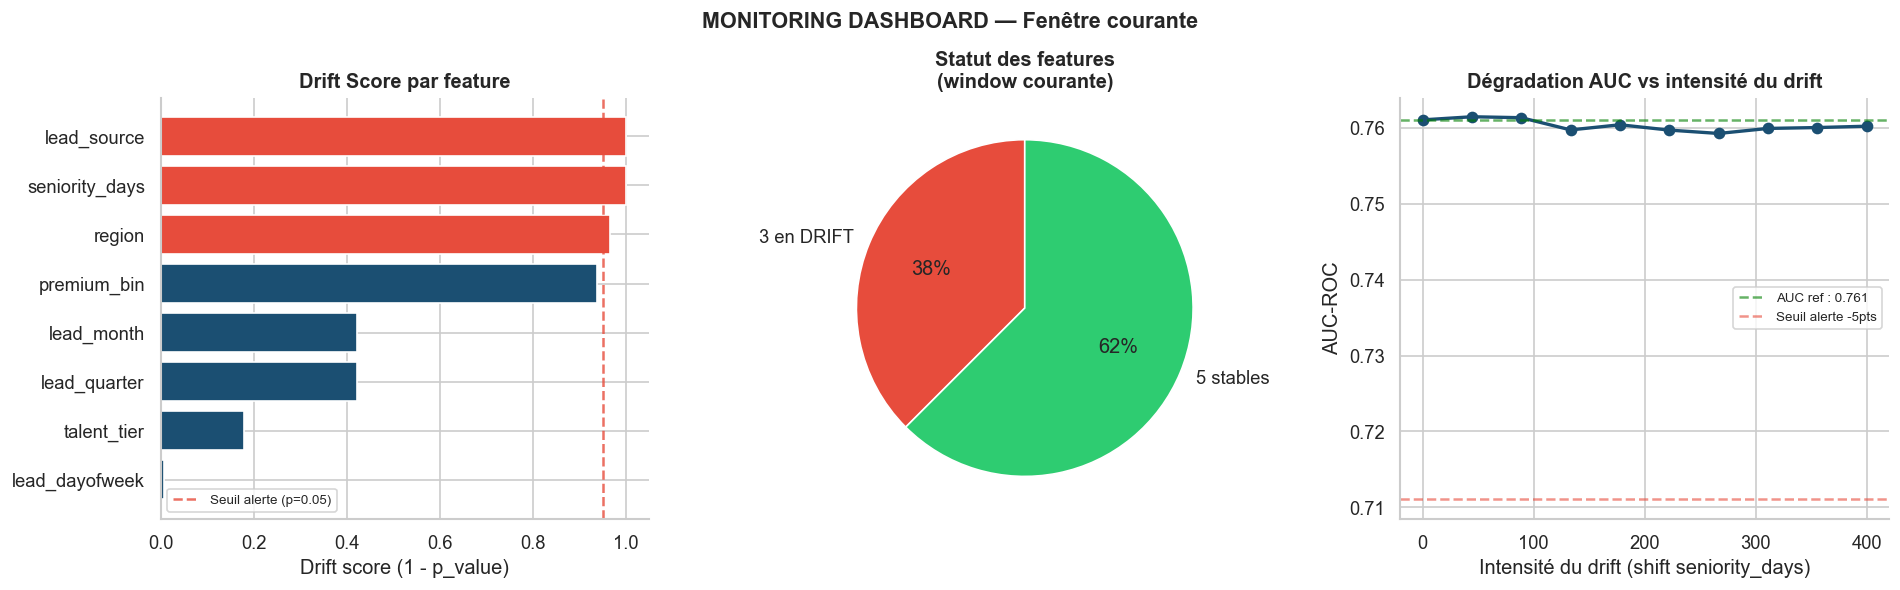

In [20]:
# ── DASHBOARD DE MONITORING — Vue synthétique ─────────────────────────────
# C'est ce que tu mettrais dans un rapport mensuel automatisé

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1 : Score de drift par feature (1 - p_value normalisée)
drift_report_clean = drift_report.dropna(subset=['p_value']).copy()
drift_report_clean['drift_score'] = 1 - drift_report_clean['p_value'].clip(0, 1)
drift_report_clean = drift_report_clean.sort_values('drift_score', ascending=True)

bar_colors = [COLOR_SEC if d else COLOR_PRI for d in drift_report_clean['drift']]
axes[0].barh(drift_report_clean['feature'], drift_report_clean['drift_score'], color=bar_colors)
axes[0].axvline(0.95, color=COLOR_SEC, linestyle='--', alpha=0.8, label='Seuil alerte (p=0.05)')
axes[0].set_xlabel('Drift score (1 - p_value)')
axes[0].set_title('Drift Score par feature', fontweight='bold')
axes[0].legend(fontsize=8)

# Panel 2 : Résumé du statut
n_drift  = drift_report['drift'].sum()
n_ok     = (~drift_report['drift']).sum()
wedge_colors = [COLOR_SEC, '#2ECC71']
axes[1].pie([n_drift, n_ok], labels=[f'{n_drift} en DRIFT', f'{n_ok} stables'],
           autopct='%1.0f%%', colors=wedge_colors, startangle=90)
axes[1].set_title('Statut des features\n(window courante)', fontweight='bold')

# Panel 3 : AUC simulée sur fenêtres glissantes
# (simulation : on perturbe progressivement les données pour voir la dégradation)
drift_intensities = np.linspace(0, 400, 10)
auc_trend         = []
for intensity in drift_intensities:
    X_tmp = X_test.copy()
    X_tmp['seniority_days'] = X_test['seniority_days'] + intensity
    proba_tmp = best_pipeline.predict_proba(X_tmp)[:, 1]
    auc_trend.append(roc_auc_score(y_test, proba_tmp))

axes[2].plot(drift_intensities, auc_trend, color=COLOR_PRI, marker='o', linewidth=2)
axes[2].axhline(auc_normal, color='green',  linestyle='--', alpha=0.6, label=f'AUC ref : {auc_normal:.3f}')
axes[2].axhline(auc_normal - 0.05, color=COLOR_SEC, linestyle='--', alpha=0.6, label='Seuil alerte -5pts')
axes[2].fill_between(drift_intensities, auc_trend, auc_normal - 0.05, 
                    where=[a < auc_normal - 0.05 for a in auc_trend],
                    alpha=0.2, color=COLOR_SEC)
axes[2].set_xlabel('Intensité du drift (shift seniority_days)')
axes[2].set_ylabel('AUC-ROC')
axes[2].set_title('Dégradation AUC vs intensité du drift', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('MONITORING DASHBOARD — Fenêtre courante', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Synthèse & Décisions de Réentraînement

| Signal | Seuil | Action |
|--------|-------|--------|
| p_value KS/Chi² < 0.05 sur 1 feature | ⚠️ Avertissement | Investiguer la source du drift |
| p_value KS/Chi² < 0.05 sur ≥ 3 features | 🚨 Alerte | Réentraîner le modèle |
| Delta AUC > -2pts | ✅ Stable | Monitoring mensuel |
| Delta AUC entre -2pts et -5pts | ⚠️ Avertissement | Augmenter la fréquence de monitoring |
| Delta AUC > -5pts | 🚨 Alerte | Réentraînement immédiat + investigation |

**Prochaines évolutions :**
- Automatiser ce rapport en **job mensuel** (Airflow / cron)
- Stocker les métriques dans une table `model_monitoring` en base
- Mettre en place des **alertes Slack/email** quand un seuil est franchi
- Explorer **Evidently AI** ou **NannyML** pour un monitoring plus complet en prod